# 홈 서버 공격 로그 비지도학습 분석

## 개요
Suricata(IDS)가 수집한 방화벽 공격 로그를 비지도 머신러닝으로 분석하여, 우리 서버를 노린 공격자들이 어떤 행동 유형으로 나뉘는지 자동으로 분류한다. 직접 집에 구축한 홈랩 서버(Proxmox 가상화 위 pfSense 방화벽 + Suricata IDS)의 방화벽 로그를 데이터로 준비했고, 양은 약 8만 줄이다.
기존 IDS는 시그니처(미리 정의된 규칙)로 개별 공격을 탐지하지만, "어떤 공격자가 어떤 목적을 가졌는지"는 알려주지 않는다. 본 분석은 라벨이 없는 로그를 비지도 학습으로 묶어, 사람이 일일이 분류하지 않고도 공격자 유형을 자동으로 도출하는 것을 목표로 한다.

## 데이터 준비
홈랩의 pfSense에서 동작하는 Suricata가 28일간(2026-06-01 ~ 06-29) 기록한 경보 로그(alerts.log)를 사용했다. 원본은 [**], {TCP}, -> 같은 기호가 섞인 텍스트 형태라 그대로 분석할 수 없어, 정규식으로 한 줄에서 10개 필드(발생 시각·시그니처 ID·시그니처명·분류·위험도·프로토콜·출발 IP/포트·도착 IP/포트)를 추출해 구조화된 표로 변환했다. 82,918건 전부가 누락 없이 파싱되었다.

## 1. 라이브러리 로드

In [1]:
#데이터를 불러올 때 필요한 라이브러리들
import os
from google.colab import files
from google.colab import drive

#데이터를 분석하고 가공하는 데 필요한 라이브러리들
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import ipaddress

#모델을 학습시킬 때 필요한 라이브러리들
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 2. 드라이브 마운트 및 Raw 데이터 경로 지정
런타임이 끊겨도 파일이 유지되도록 구글 드라이브를 마운트하고, 로그 경로를 상수로 고정한다.

In [5]:
# if not os.path.ismount('/content/drive'):
#   drive.mount('/content/drive')
# LOG_PATH = '/content/drive/MyDrive/security_ai/alerts.log' # 로그 경로 상수
# PATH = '/content/drive/MyDrive/security_ai/' # 로그 폴더 경로 상수
PATH = '../data/' # 로그 폴더 경로 상수
LOG_PATH = PATH + 'sample_alerts.log' # 로그 경로 상수
with open(LOG_PATH) as f:
    print(f.readline()) # Raw 데이터 로드 확인

06/01/2026-04:01:06.785351  [**] [1:2210054:1] SURICATA STREAM excessive retransmissions [**] [Classification: Generic Protocol Command Decode] [Priority: 3] {TCP} 208.123.73.209:443 -> 192.168.45.3:23895



## 3. Raw 로그 → DataFrame (정규식 파싱)
Raw 로그는 `[**]`, `{TCP}`, `->` 같은 기호가 섞인 날것의 텍스트라 바로 분석할 수 없다.

정규식으로 한 줄에서 **10개 필드** 날짜, 시그니처ID, 설명, 클래스, 위험도, 프로토콜, 출발IP/포트, 도착IP/포트를 추출해 데이터프레임으로 만든다.

In [ ]:
# 정규식 정리 후 합치기
with open(LOG_PATH, 'r', encoding='utf-8') as f:
    # lines = f.readlines()[:5]
    regex = r"(^\d{2}/\d{2}/\d{4}-\d{2}:\d{2}:\d{2}\.\d{6})\s+\[\*\*\]\s+\[\d+:(\d+):\d+\]\s+(.+?)\s+\[\*\*\]\s+\[Classification:\s+(.+?)\]\s+\[Priority:\s(\d)\]\s+\{(.+?)\}\s+(\d+\.\d+\.\d+\.\d+):(\d+)\s+->\s+(\d+\.\d+\.\d+\.\d+):(\d+)"
    rows = []
    for line in f:
      t = re.search(regex, line).groups()
      if(t):
        rows.append(t)
    print("행 개수 : "+str(len(rows))+"\n")
    print("첫째 행 : "+str(rows[0]))

행 개수 : 82918

첫째 행 : ('06/01/2026-04:01:06.785351', '2210054', 'SURICATA STREAM excessive retransmissions', 'Generic Protocol Command Decode', '3', 'TCP', '208.123.73.209', '443', '192.168.45.3', '23895')


**파싱 결과를 DataFrame으로 만들고 자료형을 변환한다.**- 날짜 → datetime (시간 분석 가능)- 시그니처ID·위험도·포트 → int (계산·정렬 가능)

In [ ]:
df = pd.DataFrame(rows,columns=["날짜","시그니처","설명","클래스","위험도","프로토콜","출발 IP","출발 포트","도착 IP","도착 포트"])
df["날짜"] = pd.to_datetime(df["날짜"],format='%m/%d/%Y-%H:%M:%S.%f')
df["시그니처"] = df["시그니처"].astype(int)
df["위험도"] = df["위험도"].astype(int)
df["출발 포트"] = df["출발 포트"].astype(int)
df["도착 포트"] = df["도착 포트"].astype(int)

In [ ]:
print(df.shape)
df.head()

(82918, 10)


,날짜,시그니처,설명,클래스,위험도,프로토콜,출발 IP,출발 포트,도착 IP,도착 포트
0,2026-06-01 04:01:06.785351,2210054,SURICATA STREAM excessive retransmissions,Generic Protocol Command Decode,3,TCP,208.123.73.209,443,192.168.45.3,23895
1,2026-06-01 05:09:58.383046,2001219,ET SCAN Potential SSH Scan,Attempted Information Leak,2,TCP,195.250.20.4,39378,192.168.45.3,22
2,2026-06-01 05:10:12.268873,2010935,ET SCAN Suspicious inbound to MSSQL port 1433,Potentially Bad Traffic,2,TCP,195.250.20.4,11494,192.168.45.3,1433
3,2026-06-01 05:10:12.397323,2010937,ET SCAN Suspicious inbound to mySQL port 3306,Potentially Bad Traffic,2,TCP,195.250.20.4,30510,192.168.45.3,3306
4,2026-06-01 05:10:13.297389,2010935,ET SCAN Suspicious inbound to MSSQL port 1433,Potentially Bad Traffic,2,TCP,195.250.20.4,11494,192.168.45.3,1433


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82918 entries, 0 to 82917
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      82918 non-null  datetime64[ns]
 1   시그니처    82918 non-null  int64         
 2   설명      82918 non-null  object        
 3   클래스     82918 non-null  object        
 4   위험도     82918 non-null  int64         
 5   프로토콜    82918 non-null  object        
 6   출발 IP   82918 non-null  object        
 7   출발 포트   82918 non-null  int64         
 8   도착 IP   82918 non-null  object        
 9   도착 포트   82918 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 6.3+ MB


**파싱 결과를 CSV로 저장** — 다음부터는 무거운 파싱을 다시 안 하고 이 파일을 바로 불러올 수 있다.

In [ ]:
df.to_csv(PATH + 'alerts_df.csv', index=False)

## 4. 데이터 분석
머신러닝을 진행하기 전 데이터의 특징과 형태를 분석해야 할 필요가 있다.

### 공격 IP의 국가, ISP 조회

가장 많이 공격한 IP들이 어느 국가·통신사에서 왔는지 확인한다.

In [ ]:
top_ips = df['출발 IP'].value_counts().head(10)
# df['도착 포트'].value_counts().head(10)
for ip in top_ips.index:
  r = requests.get(f"http://ip-api.com/json/{ip}").json()
  print(r['country'], '|', r['isp'], '|', r['org'])

The Netherlands | Offshore LC | Storm Industries
United Kingdom | Skynet Network LTD | Limited Network LTD
The Netherlands | Pfcloud UG (haftungsbeschrankt) | Pfcloud UG
United Kingdom | Skynet Network LTD | Limited Network LTD
The Netherlands | Techoff SRV Limited | Techoff SRV Limited
United Kingdom | Skynet Network LTD | Limited Network LTD
United Kingdom | Skynet Network LTD | Limited Network LTD
The Netherlands | Techoff SRV Limited | Techoff SRV Limited
United Kingdom | Skynet Network LTD | Limited Network LTD
United Kingdom | Skynet Network LTD | Limited Network LTD


### 기본 통계공격 분류, 시그니처, 위험도 분포를 본다.

공격 분류의 약 97%가 "Misc Attack"으로, 대부분 이미 알려진 악성 IP의 평판 기반 차단 트래픽이었다. 즉 표적 공격보다 인터넷 전역을 무차별로 훑는 기회주의적 봇이 압도적이었다.

In [ ]:
df['클래스'].value_counts()

,count
클래스,
Misc Attack,80443
Potentially Bad Traffic,1993
Misc activity,201
Generic Protocol Command Decode,186
Attempted Information Leak,82
Attempted Administrator Privilege Gain,10
Potential Corporate Privacy Violation,3


가장 많이 노려진 포트는 웹(443, 80), Telnet(23), SSH(22) 등 실제 서비스 포트였으며, 동시에 30,000종이 넘는 높은 포트가 한두 번씩 스캔되어 무차별 포트 스캐닝의 흔적이 뚜렷했다.

In [ ]:
df['도착 포트'].value_counts().head(10)

,count
도착 포트,
443,1640
1433,1197
80,1093
25565,1065
5432,634
5900,586
27015,570
3306,552
2222,499


In [ ]:
df['도착 포트'].nunique()

30813

In [ ]:
df['설명'].value_counts().head(10)

,count
설명,
ET DROP Dshield Block Listed Source group 1,18841
ET DROP Spamhaus DROP Listed Traffic Inbound group 7,4401
ET DROP Spamhaus DROP Listed Traffic Inbound group 36,1866
ET CINS Active Threat Intelligence Poor Reputation IP group 286,1167
ET DROP Spamhaus DROP Listed Traffic Inbound group 28,999
ET SCAN Suspicious inbound to MSSQL port 1433,974
ET CINS Active Threat Intelligence Poor Reputation IP group 285,957
ET CINS Active Threat Intelligence Poor Reputation IP group 266,941
ET CINS Active Threat Intelligence Poor Reputation IP group 117,919


In [ ]:
df['위험도'].value_counts().sort_index()

,count
위험도,
1,13
2,82518
3,387


In [ ]:
df['프로토콜'].value_counts(normalize=True)

,proportion
프로토콜,
TCP,0.927374
UDP,0.070057
ICMP,0.002569


### 최고 위험 이벤트 확인

가장 위험하게 분류된 이벤트들을 직접 까봤더니 대부분 Cloudflare 경유 정찰이거나 내부 정상 트래픽(Steam 등)인 오탐임이 드러난다.

이는 시그니처 기반 분류만으로는 진짜 위협과 노이즈를 구분하기 어렵다는 점을 보여준다.

In [ ]:
df[df['위험도'] == 1]

,날짜,시그니처,설명,클래스,위험도,프로토콜,출발 IP,출발 포트,도착 IP,도착 포트
3953,2026-06-06 12:54:41.559951,2033603,ET EXPLOIT GraphQL Introspection Query Attempt,Attempted Administrator Privilege Gain,1,TCP,108.162.241.21,10167,192.168.45.3,80
3954,2026-06-06 12:54:41.782681,2033603,ET EXPLOIT GraphQL Introspection Query Attempt,Attempted Administrator Privilege Gain,1,TCP,108.162.241.21,10167,192.168.45.3,80
3955,2026-06-06 12:54:41.920604,2033603,ET EXPLOIT GraphQL Introspection Query Attempt,Attempted Administrator Privilege Gain,1,TCP,172.70.80.21,9950,192.168.45.3,80
3956,2026-06-06 12:54:42.070079,2033603,ET EXPLOIT GraphQL Introspection Query Attempt,Attempted Administrator Privilege Gain,1,TCP,172.64.192.76,11314,192.168.45.3,80
3958,2026-06-06 12:54:42.104167,2033603,ET EXPLOIT GraphQL Introspection Query Attempt,Attempted Administrator Privilege Gain,1,TCP,172.69.130.234,11659,192.168.45.3,80
3959,2026-06-06 12:54:42.327498,2033603,ET EXPLOIT GraphQL Introspection Query Attempt,Attempted Administrator Privilege Gain,1,TCP,172.69.195.144,12951,192.168.45.3,80
3960,2026-06-06 12:54:42.328351,2033603,ET EXPLOIT GraphQL Introspection Query Attempt,Attempted Administrator Privilege Gain,1,TCP,172.69.130.234,11659,192.168.45.3,80
3961,2026-06-06 12:54:42.594950,2033603,ET EXPLOIT GraphQL Introspection Query Attempt,Attempted Administrator Privilege Gain,1,TCP,172.64.192.76,11314,192.168.45.3,80
3962,2026-06-06 12:54:42.886167,2033603,ET EXPLOIT GraphQL Introspection Query Attempt,Attempted Administrator Privilege Gain,1,TCP,172.68.229.91,9716,192.168.45.3,80
3964,2026-06-06 12:54:43.419123,2033603,ET EXPLOIT GraphQL Introspection Query Attempt,Attempted Administrator Privilege Gain,1,TCP,172.71.178.66,13360,192.168.45.3,80


### 시간 분석날짜를 datetime으로 변환해뒀으므로 시간대별 추이를 뽑을 수 있다.

In [ ]:
df['시'] = df['날짜'].dt.hour          # 0~23시 새 열 추가
df['요일'] = df['날짜'].dt.dayofweek    # 0=월 ~ 6=일
df['날'] = df['날짜'].dt.date          # 날짜만 (시간 떼고)

df['시'].value_counts().sort_index()    # 시간대별 공격량
df['날'].value_counts().sort_index()    # 일별 추이

,count
날,
2026-06-01,72
2026-06-02,118
2026-06-03,252
2026-06-04,1240
2026-06-05,1430
2026-06-06,1455
2026-06-07,1317
2026-06-08,1342
2026-06-09,2237


## 5. 분석 대상 정리
수집된 로그에는 분석 대상이 아닌 트래픽이 섞여 있었다. 방화벽 오탐으로 내부(LAN)에서 외부로 나가는 트래픽이 차단된 기록(예: 내부에서 실행한 Steam)과 내부망 사설 IP 간 통신이 그것이다.

먼저 사설 IP에서 발생한 트래픽을 확인한 뒤, 도착지가 내 서버이면서 출발지가 사설 IP가 아닌 것, 즉 외부에서 유입된 공격만 남겼다.

그 결과 82,918건 중 82,779건이 분석 대상으로 확정되었다. 단, 진짜 공격인지 애매한 노이즈는 제거하지 않고 클러스터링이 스스로 분리하도록 남겨두었다.

**사설 IP 확인** — 내부망에서 온 트래픽이 뭐가 있는지 본다.

In [ ]:
def is_private(ip):
    return ipaddress.ip_address(ip).is_private

# 출발 IP가 사설인 행만
private_src = df[df['출발 IP'].apply(is_private)]
print("사설 출발 IP 행 수:", len(private_src))
print(private_src['출발 IP'].value_counts())   # 어떤 사설 IP들인지

사설 출발 IP 행 수: 139
출발 IP
192.168.45.3     93
10.0.2.2         20
192.168.1.102    12
192.168.45.2      9
10.0.20.10        5
Name: count, dtype: int64


**외부 인입 공격만 필터링**

In [ ]:
def is_private(ip):
    return ipaddress.ip_address(ip).is_private

# 1. 들어오는 것만 (도착 = 내 서버)  + 2. 출발이 사설이 아닌 것
inbound = df[
    (df['도착 IP'] == '192.168.45.3') &
    (~df['출발 IP'].apply(is_private))
].copy()

print("전체:", len(df), "→ 외부 인입 공격:", len(inbound))

전체: 82918 → 외부 인입 공격: 82779


## 6. 공격 유형 분류시그니처(설명)
시그니처(설명) 안의 키워드로 각 공격을 유형별로 분류하는 열을 만들었다.

ET·SURICATA·GPL 등 룰셋 출처가 달라도 키워드 기반이라 모두 커버할 수 있도록 설계했다.

분류 결과, 기존 블랙리스트에 등록된 평판 차단 유형이 약 97%로 압도적이었으며, 그 외 스캔·핑 정찰·프로토콜 잡음·익스플로잇이 소수를 차지했다. '기타'로 새는 항목이 없도록 키워드를 보완해 분류를 완성했다.

In [ ]:
def 분류(설명):
    if 'SCAN' in 설명:
        return '스캔'
    elif 'DROP' in 설명 or 'CINS' in 설명 or 'Spamhaus' in 설명 \
         or 'Dshield' in 설명 or 'COMPROMISED' in 설명:   # ← COMPROMISED 추가
        return '평판차단'
    elif 'EXPLOIT' in 설명 or 'WebShell' in 설명 or 'WEB_SERVER' in 설명:  # ← 웹공격 추가
        return '익스플로잇'
    elif 'MALWARE' in 설명:
        return '악성코드'
    elif 'ICMP' in 설명 or 'PING' in 설명:
        return '핑정찰'
    elif 'STREAM' in 설명 or 'Applayer' in 설명 or 'HTTP' in 설명 or 'DNS' in 설명 \
         or 'TLS' in 설명 or 'QUIC' in 설명 or 'IKE' in 설명:
        return '프로토콜잡음'
    elif 'POLICY' in 설명:
        return '정책위반'
    else:
        return '기타'

inbound['공격유형'] = inbound['설명'].apply(분류)
inbound['공격유형'].value_counts()

,count
공격유형,
평판차단,80443
스캔,2022
핑정찰,175
프로토콜잡음,127
익스플로잇,12


'기타'로 분류된 게 있는지 확인

In [ ]:
inbound[inbound['공격유형'] == '기타']['설명'].value_counts()

,count
설명,


## 7. 피처 엔지니어링
머신러닝을 진행할 때 기준이 되는 7개의 피처를 만들었다.

| 피처 | 가르는 차이 |
| :--- | ---: |
| 총횟수 | 끈질긴 공격자 vs 한두 번 스친 봇 |
| 포트종류수 | 특정 서비스 표적형 vs 무차별 스캐너 |
| 시그니처종류수 | 단순한 수법 vs 다양한 수법 |
| UDP비율 | UDP 기반 스캐너(게임·SIP) 분리 |
| SCAN비율 | 정찰형 vs 그 외 |
| 위험도 | 실제 위험한 공격을 시도한 IP 식별 (4-위험도로 뒤집어 큰 값이 위험) |
| 활동기간_분 | 잠깐 스친 봇 vs 며칠간 머문 봇 |

피처 선정 과정에서 IP 주소나 출발 포트처럼 공격자의 성향과 무관한 값은 제외했다.

예를 들어 "웰노운 포트(1024 미만) 비율"을 후보로 검토했으나, MSSQL(1433)·RDP(3389) 등 1024 이상에도 명백한 서비스 포트가 많아 기준이 부정확하다고 판단하여,

대신 "포트 종류 수"가 표적형과 무차별형을 더 잘 구분함을 확인하고 채택했다.

총 7개의 피처를 통해 각각의 로그 특징을 자세하게 구분 가능하게 됐다.

In [ ]:
g = inbound.groupby('출발 IP')

# 활동 기간(초) 미리 계산
기간 = g['날짜'].apply(lambda x: (x.max() - x.min()).total_seconds())

feat = pd.DataFrame({
    '총횟수': g.size(),
    '포트종류수': g['도착 포트'].nunique(),
    '시그니처종류수': g['설명'].nunique(),
    'UDP비율': g.apply(lambda x: (x['프로토콜'] == 'UDP').mean()),
    'SCAN비율': g.apply(lambda x: x['설명'].str.contains('SCAN').mean()),
    '위험도': g['위험도'].apply(lambda x: (4 - x).max()),
    '활동기간_분': 기간 / 60,
})
feat.head()
feat.describe()

/tmp/ipykernel_754/4156610740.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'UDP비율': g.apply(lambda x: (x['프로토콜'] == 'UDP').mean()),
/tmp/ipykernel_754/4156610740.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'SCAN비율': g.apply(lambda x: x['설명'].str.contains('SCAN').mean()),


,총횟수,포트종류수,시그니처종류수,UDP비율,SCAN비율,위험도,활동기간_분
count,10726.000000,10726.000000,10726.000000,10726.000000,10726.000000,10726.000000,10726.000000
mean,7.717602,6.139940,2.118777,0.149172,0.081345,1.990863,8816.253405
std,21.357731,16.245618,1.695811,0.344701,0.254579,0.101781,10668.567168
min,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000
50%,2.000000,2.000000,1.000000,0.000000,0.000000,2.000000,2994.749883
75%,4.000000,4.000000,3.000000,0.000000,0.000000,2.000000,16919.453726
max,545.000000,471.000000,14.000000,1.000000,1.000000,3.000000,39788.661476


## 8. 전처리
클러스터링은 점 사이의 거리로 군집을 묶으므로 거리 계산이 공정해야 한다.

하지만 각 피처는 수집 방식이 달라 값의 범위가 제각각이다.

총횟수·활동기간처럼 소수의 값이 극단적으로 큰(한쪽으로 쏠린) 피처는 로그 변환(log1p)으로 분포를 완만하게 폈고,

범위가 제각각인 피처들(횟수 1\~545 vs 비율 0\~1)은 표준화(StandardScaler)로 평균 0·표준편차 1에 맞춰, 모든 피처가 거리 계산에 동등하게 기여하도록 했다.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

feat_log = np.log1p(feat)
X = StandardScaler().fit_transform(feat_log)
print(X[:5])

[[-7.75296036e-01 -7.22246800e-01 -8.13882069e-01 -4.38979699e-01
   3.52714561e+00  9.31190295e-02 -1.16020407e+00]
 [ 1.25704260e+00  1.08588333e+00 -8.13882069e-01  2.44618645e+00
  -3.27143120e-01  9.31190295e-02  1.02329457e+00]
 [-7.75296036e-01 -7.22246800e-01 -8.13882069e-01 -4.38979699e-01
  -3.27143120e-01  9.31190295e-02 -1.16020407e+00]
 [-7.75296036e-01 -7.22246800e-01 -8.13882069e-01 -4.38979699e-01
   3.52714561e+00  9.31190295e-02 -1.16020407e+00]
 [-3.51822011e-01 -2.66725233e-01 -8.13882069e-01  2.44618645e+00
  -3.27143120e-01  9.31190295e-02 -4.73366503e-04]]


## 9. 클러스터링 (K-means)

군집 개수 k를 3~8까지 바꿔가며 실루엣 계수(군집이 얼마나 잘 분리됐는지를 나타내는 지표, 1에 가까울수록 좋음)로 최적값을 탐색했다.

k=7에서 0.632로 가장 높았고 k=8에서 하락하여, 7개 군집으로 확정했다.

In [ ]:
for k in range(3, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}  실루엣={score:.3f}")

k=3  실루엣=0.400
k=4  실루엣=0.426
k=5  실루엣=0.503
k=6  실루엣=0.600
k=7  실루엣=0.632
k=8  실루엣=0.598


**k=7 군집이 실루엣 0.632로 최고.**

7개 유형으로 확정하고 각 IP에 군집 번호를 붙인다.

In [ ]:
km = KMeans(n_clusters=7, n_init=10, random_state=42)
feat['군집'] = km.fit_predict(X)

feat['군집'].value_counts().sort_index()   # 군집별 IP 개수

,count
군집,
0,3740
1,2903
2,872
3,1536
4,105
5,697
6,873


## 10. 군집 해석

알고리즘은 번호만 준다. 각 군집의 피처 평균을 보고 **사람이 의미를 부여**한다.


| 군집 | IP 수 | 유형 | 특징 |
| :--- | :---: | :---: | ---: |
| 0 | 3,740 | 평판차단봇(장기 체류) | 적은 횟수로 며칠간 띄엄띄엄 두드림 |
| 1 | 2,903 | 단발 스쳐간 봇 | 1회 접속 후 사라진 기회주의적 트래픽 |
| 2 | 872 | UDP 단발 스캐너 | UDP로 한 포트만 찍고 이탈 |
| 3 | 1,536 | 잡식 헤비 스캐너 | 가장 공격적 — 포트 30종 이상 무차별 스캔, 장기 체류 |
| 4 | 105 | 노이즈·오탐 집단 | 핑·프로토콜 디코딩 오류 등 실제 공격 아님 |
| 5 | 697 | UDP 다중포트 스캐너 | UDP로 여러 포트 스캔(게임 서버 등 표적) |
| 6 | 873 | SCAN 정찰형 | ET SCAN 시그니처 위주의 명시적 정찰 |

특히 군집 4는 실제로 어떤 공격을 했는지 확인한 결과 핑(ICMP)과 HTTP/TCP 디코딩 오류 등 실제 공격이 아닌 노이즈성 이벤트가 대부분이었다.

이런 오탐이 사람의 개입 없이 별도 군집으로 자동 분리된 것이 본 분석의 핵심 성과다.

— 비지도 학습이 IDS 오탐을 사후 식별할 수 있음을 실증한다.

In [ ]:
feat.groupby('군집').mean()   # 군집별 7개 피처 평균

,총횟수,포트종류수,시그니처종류수,UDP비율,SCAN비율,위험도,활동기간_분
군집,,,,,,,
0,3.881283,3.283422,2.313636,0.012183,0.018086,2.000000,12608.918333
1,1.054082,1.027902,1.018257,0.000000,0.000344,2.001033,9.433065
2,1.044725,1.026376,1.004587,1.000000,0.000573,2.000000,9.229182
3,38.873698,30.239583,4.755208,0.029799,0.008117,2.000000,24294.413106
4,2.485714,1.009524,1.028571,0.066667,0.114286,1.000000,645.094210
5,4.008608,3.106169,2.381636,0.903416,0.003145,2.000000,12084.145314
6,1.749141,1.121420,1.339061,0.000000,0.889696,2.004582,1791.231061


**군집 4(소수 집단)가 실제로 뭘 했는지 확인** — 핑·프로토콜 잡음이 대부분임이 드러난다.

In [ ]:
# 군집 4 IP들이 실제로 뭘 했나
clust4_ips = feat[feat['군집'] == 4].index
inbound[inbound['출발 IP'].isin(clust4_ips)]['설명'].value_counts().head(10)

,count
설명,
GPL ICMP PING *NIX,143
SURICATA HTTP unable to match response to request,68
SURICATA STREAM Packet with invalid timestamp,14
ET SCAN LeakIX Inbound User-Agent,12
SURICATA DNS Z flag set,6
GPL ICMP PING BSDtype,6
SURICATA STREAM excessive retransmissions,5
SURICATA Applayer Mismatch protocol both directions,3
SURICATA QUIC failed decrypt,2


In [ ]:
feat[feat['군집'] == 4].index

Index(['104.23.175.131', '108.162.241.27', '109.248.43.169', '141.101.98.47',
       '146.75.50.132', '151.101.66.132', '152.44.39.169', '154.213.178.159',
       '156.38.157.201', '162.158.216.76',
       ...
       '89.124.8.77', '89.46.236.111', '89.46.237.19', '94.237.115.150',
       '94.237.118.119', '94.237.119.86', '94.237.35.1', '94.237.39.81',
       '94.237.52.110', '94.237.7.37'],
      dtype='object', name='출발 IP', length=105)

## 11. 시각화

분석 결과를 다섯 가지로 시각화했다.

1. 군집별 IP 분포(막대그래프)
2. PCA 2차원 투영 산점도
3. 가장 많이 노려진 포트
4. 공격 유형 분포(로그 스케일)
5. 군집별 행동 특성 히트맵

특히 PCA 산점도에서 7개 군집이 색깔별로 뚜렷이 분리되어, 높은 실루엣 계수(0.632)가 시각적으로도 확인되었다.

히트맵에서는 각 군집이 어떤 피처에서 두드러지는지가 한눈에 드러나, 군집 해석을 뒷받침했다.

한글 폰트를 먼저 설치한다 (matplotlib 기본은 한글이 깨짐).

In [ ]:
!apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
print("폰트 준비 완료")

폰트 준비 완료


### 군집별 IP 개수

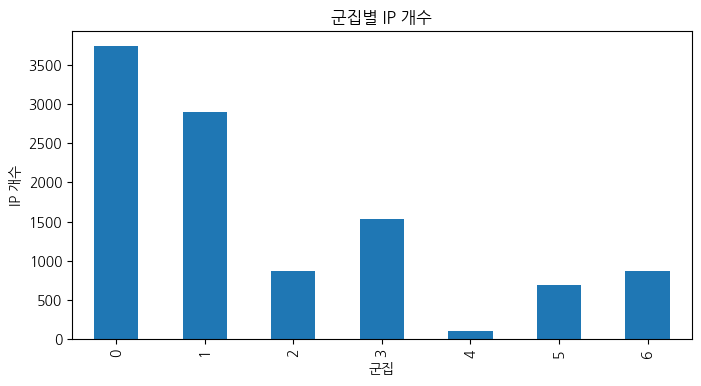

In [ ]:
plt.figure(figsize=(8, 4))
feat['군집'].value_counts().sort_index().plot(kind='bar')
plt.title('군집별 IP 개수')
plt.xlabel('군집')
plt.ylabel('IP 개수')
plt.show()

### 공격자 행동 군집 (PCA 2D 투영)

7차원 피처를 2차원으로 압축해 군집이 공간에서 분리되는 것을 시각적으로 확인한다.

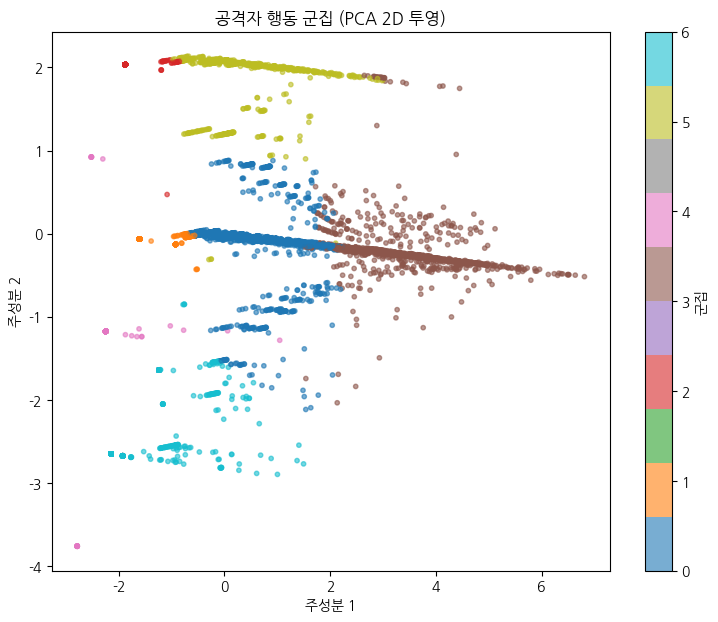

정보 보존율: 0.637


In [ ]:
from sklearn.decomposition import PCA

# 7차원 X를 2차원으로 압축
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# 산점도 (군집별 색깔)
plt.figure(figsize=(9, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1],
                      c=feat['군집'], cmap='tab10', s=10, alpha=0.6)
plt.title('공격자 행동 군집 (PCA 2D 투영)')
plt.xlabel('주성분 1')
plt.ylabel('주성분 2')
plt.colorbar(scatter, label='군집')
plt.show()

print("정보 보존율:", pca.explained_variance_ratio_.sum().round(3))

### 가장 많이 노려진 포트

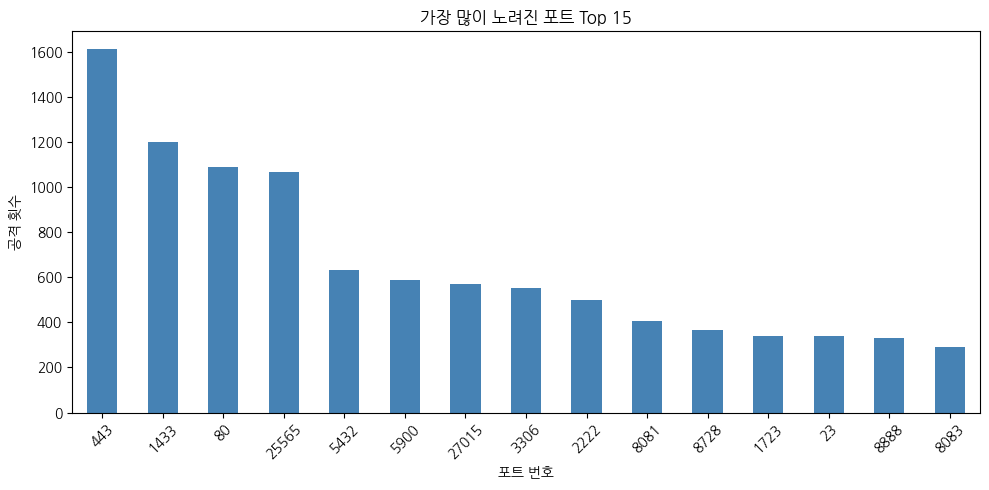

In [ ]:
plt.figure(figsize=(10, 5))
top_ports = inbound['도착 포트'].value_counts().head(15)
top_ports.plot(kind='bar', color='steelblue')
plt.title('가장 많이 노려진 포트 Top 15')
plt.xlabel('포트 번호')
plt.ylabel('공격 횟수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 공격 유형 분포평판

차단이 압도적이라 로그 스케일로 그려 나머지도 보이게 한다.

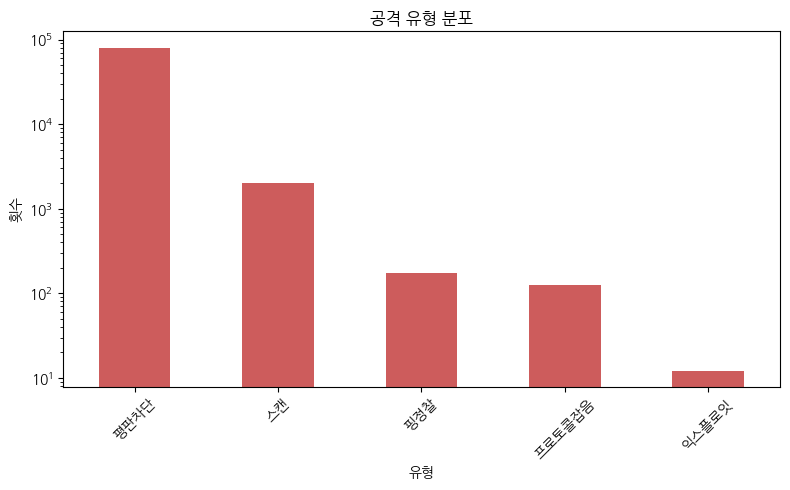

In [ ]:
plt.figure(figsize=(8, 5))
inbound['공격유형'].value_counts().plot(kind='bar', color='indianred')
plt.title('공격 유형 분포')
plt.xlabel('유형')
plt.ylabel('횟수')
plt.xticks(rotation=45)
plt.yscale('log')   # 평판차단이 압도적이라 로그 스케일로 (안 그러면 나머지가 안 보임)
plt.tight_layout()
plt.show()

### 일별 공격 추이

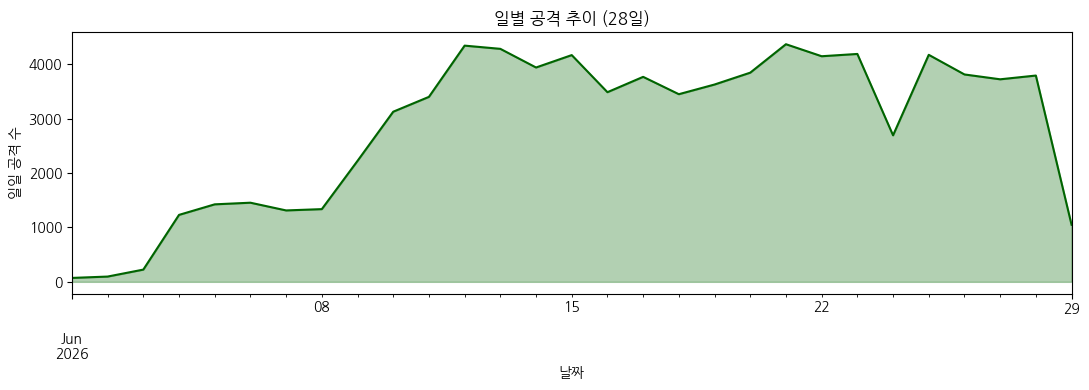

In [ ]:
plt.figure(figsize=(11, 4))
daily = inbound.set_index('날짜').resample('D').size()
daily.plot(color='darkgreen')
plt.fill_between(daily.index, daily.values, alpha=0.3, color='darkgreen')
plt.title('일별 공격 추이 (28일)')
plt.xlabel('날짜')
plt.ylabel('일일 공격 수')
plt.tight_layout()
plt.show()

### 군집별 행동 특성 히트맵

7군집 × 7피처를 색으로 표현. 진할수록 그 피처가 높다 — 각 군집의 정체를 한눈에 보여준다.

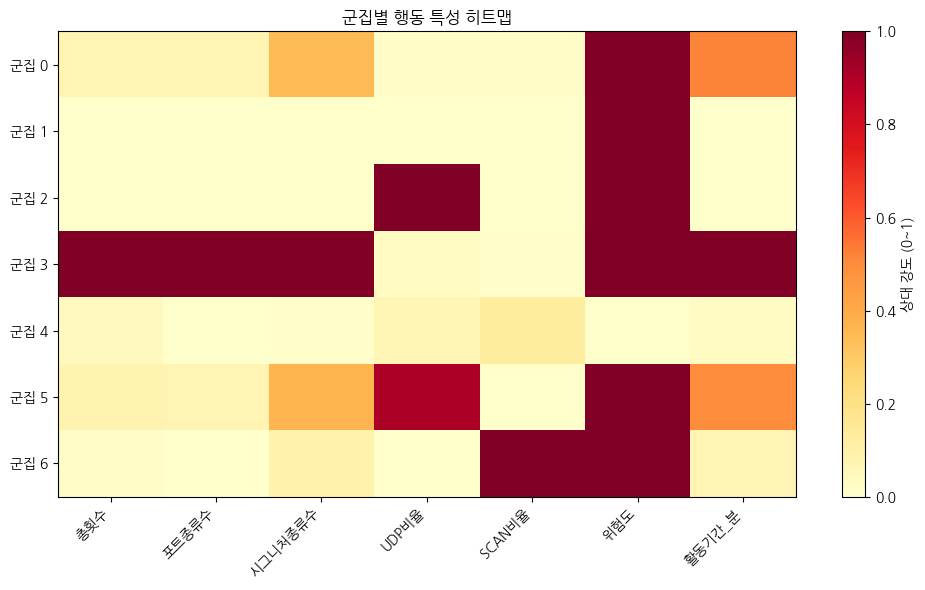

In [ ]:
import numpy as np

# 군집별 평균 (스케일된 X 기준 — 피처 간 비교가 공정하게)
clust_profile = feat.groupby('군집').mean()

# 색 비교 공정하게: 각 피처를 0~1로 정규화
normed = (clust_profile - clust_profile.min()) / (clust_profile.max() - clust_profile.min())

plt.figure(figsize=(10, 6))
plt.imshow(normed, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='상대 강도 (0~1)')
plt.xticks(range(len(normed.columns)), normed.columns, rotation=45, ha='right')
plt.yticks(range(len(normed.index)), [f'군집 {i}' for i in normed.index])
plt.title('군집별 행동 특성 히트맵')
plt.tight_layout()
plt.show()

## 12. 결론

- 실제 운영 환경(홈랩 pfSense + Suricata)에서 28일간 수집한 **82,918건**의 공격 로그를 분석했다.

- 외부 인입 공격 **82,779건**, 공격 IP **약 10,700개**를 대상으로 비지도 클러스터링을 수행했다.

- 공격 트래픽의 **약 97%는 평판 기반 차단(기회주의적 노이즈)** 이었다.

- 행동 기반 K-means(k=7, 실루엣 0.632)로 공격자를 **7개 유형**으로 자동 분류했다:  평판차단봇 / 단발봇 / UDP 단발·다중 스캐너 / 잡식 헤비 스캐너 / SCAN 정찰형 / **노이즈·오탐 집단**.

- 시그니처 기반 IDS가 놓치는 **노이즈/오탐을 별도 군집으로 자동 분리**해, 비지도 학습이 오탐 식별의 보조 수단이 될 수 있음을 실증했다.



### 13. 한계 및 향후 과제

- 수집 환경 특성상 표적 공격보다 무차별 스캔이 압도적이었다.

- Cloudflare 경유 트래픽은 출발 IP가 가려져 별도 처리가 필요하다.

- 향후 이상탐지(Isolation Forest)를 결합해 신종 공격 IP를 탐지하는 방향으로 확장할 수 있다.

### 14. 프로젝트의 의의
본 프로젝트는 단순한 학습 과제를 넘어, 보안 실무에서 요구되는 핵심 역량을 직접 경험하는 과정이었다.

* 인프라와 데이터 분석의 결합 — 직접 구축한 홈랩(Proxmox·pfSense·Suricata)에서 수집한 실데이터를 분석함으로써, 시뮬레이션 데이터가 아닌 실제 인터넷 노출 환경의 위협을 다뤘다.
인프라 구축 능력과 데이터 분석 능력을 하나의 흐름으로 연결한 점이 의미가 있다.


---


* SOC 실무와의 연결 — 보안관제(SOC)의 핵심 업무인 위협 탐지와 오탐 분류는 결국 "수많은 로그에서 의미 있는 신호를 골라내는 일"이다. 본 프로젝트에서 수행한 피처 설계와 행동 기반 군집화는 SOC의 위협 헌팅·이상 탐지 업무와 직접 맞닿아 있다.


---


* 도메인 지식의 가치 확인 — 포트 번호의 의미(서비스 식별), 시그니처 출처(ET·SURICATA·GPL)의 차이, IDS의 오탐 특성 등 보안 도메인 지식이 피처 설계의 품질을 좌우함을 체감했다. 보안 지식과 데이터 분석 역량을 함께 갖추는 것이 DevSecOps·보안 엔지니어로서의 경쟁력임을 확인했다.


---


* 향후 발전 방향 — 본 프로젝트의 경험을 바탕으로, 탐지 룰 고도화·로그 분석 자동화·이상 탐지 모델 적용 등 보안 운영의 자동화(Security Automation) 영역으로 역량을 확장해 나가고자 한다.